# Proyecto Final de Data Science

## Predicción del precio de alojamientos de Airbnb en Nueva York mediante Machine Learning

Alumno: Adrián Orué
Fecha: 25/07/2026
Curso: Data Science II

#Abstract
El presente proyecto analiza el mercado de alojamientos de Airbnb en la ciudad de Nueva York con el objetivo de comprender qué factores influyen en el precio de una propiedad y desarrollar un modelo de Machine Learning capaz de estimarlo.

Para ello se utilizaron datos públicos, técnicas de limpieza y preparación de datos, análisis exploratorio mediante visualizaciones, ingeniería de atributos y modelos supervisados de regresión.

Se entrenaron distintos modelos predictivos y, tras comparar su desempeño mediante métricas objetivas, se seleccionó XGBoost como el modelo con mejores resultados.

Este proyecto está orientado a propietarios, empresas del sector turístico, analistas de datos y cualquier organización interesada en comprender el comportamiento del mercado de alquileres temporarios.

# Motivación

Airbnb es una de las plataformas de alojamiento más utilizadas del mundo. El precio de una propiedad depende de múltiples factores como la ubicación, el tipo de habitación, la disponibilidad y la demanda.

Comprender estos factores resulta de utilidad tanto para propietarios que desean fijar precios competitivos como para empresas y analistas interesados en estudiar el mercado de alquileres temporarios.

# Audiencia

Este análisis está dirigido a:

- Propietarios de alojamientos publicados en Airbnb.
- Empresas del sector turístico.
- Analistas de datos.
- Inversores interesados en el mercado inmobiliario.
- Personas interesadas en técnicas de Ciencia de Datos y Machine Learning.

# Objetivos

## Objetivo general

Analizar los factores que influyen en el precio de los alojamientos de Airbnb y desarrollar un modelo de Machine Learning capaz de estimarlo.

## Objetivos específicos

- Obtener datos desde una fuente pública.
- Integrar información proveniente de una API.
- Limpiar y preparar los datos.
- Realizar un análisis exploratorio mediante visualizaciones.
- Aplicar ingeniería de atributos.
- Entrenar distintos modelos de Machine Learning.
- Comparar el desempeño de los modelos.
- Seleccionar el modelo con mejor rendimiento.

# Preguntas de negocio

Durante el proyecto se buscará responder las siguientes preguntas:

- ¿Qué distritos presentan los precios promedio más elevados?
- ¿Qué tipo de alojamiento posee los precios más altos?
- ¿Existe relación entre la cantidad de reseñas y el precio?
- ¿Qué variables influyen más en el precio de un alojamiento?
- ¿Es posible predecir el precio utilizando Machine Learning?

# Importación de librerías

In [1]:
# LIBRERÍAS

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import requests
import json

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import shap

import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

plt.rcParams["axes.titlesize"] = 15

plt.rcParams["axes.labelsize"] = 12

# Obtención y carga de datos

In [3]:
df = pd.read_csv("AB_NYC_2019.csv")

In [4]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
print("Filas y columnas:", df.shape)

print()

df.info()

print()

df.describe()

Filas y columnas: (48895, 16)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  l

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


# Obtención de información desde una API pública

Además del conjunto de datos principal, se realizó una consulta a una API pública para demostrar la integración de información proveniente de distintas fuentes.

Se utilizó la API Open-Meteo para obtener información climática de la ciudad de Nueva York. Los datos fueron descargados utilizando Python y almacenados en formato JSON.

In [6]:
import requests
import json

In [7]:
url = (
    "https://api.open-meteo.com/v1/forecast"
    "?latitude=40.7128"
    "&longitude=-74.0060"
    "&current=temperature_2m,relative_humidity_2m"
)

In [8]:
respuesta = requests.get(url)

clima = respuesta.json()

In [9]:
print(clima)

{'latitude': 40.710335, 'longitude': -73.99308, 'generationtime_ms': 0.06318092346191406, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 32.0, 'current_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature_2m': '°C', 'relative_humidity_2m': '%'}, 'current': {'time': '2026-07-29T07:00', 'interval': 900, 'temperature_2m': 20.7, 'relative_humidity_2m': 92}}


In [10]:
with open("weather.json","w") as archivo:

    json.dump(
        clima,
        archivo,
        indent=4
    )

In [11]:
df["current_temperature"] = clima["current"]["temperature_2m"]

df["current_humidity"] = clima["current"]["relative_humidity_2m"]

## Limpieza y preparación de los datos

En esta etapa se realizó una revisión general de la calidad del conjunto de datos. Se analizaron los tipos de variables, los valores faltantes y los registros duplicados. Posteriormente se aplicaron transformaciones básicas para dejar el dataset preparado para el análisis exploratorio y el entrenamiento de modelos de Machine Learning.

Las principales tareas realizadas fueron:

- Conversión de variables de fecha al formato adecuado.
- Tratamiento de valores faltantes.
- Verificación de registros duplicados.
- Identificación de posibles valores atípicos que serán analizados durante el EDA.

In [12]:
df.isnull().sum().sort_values(ascending=False)

,0
reviews_per_month,10052
last_review,10052
host_name,21
name,16
id,0
host_id,0
latitude,0
longitude,0
neighbourhood_group,0
neighbourhood,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [15]:
# COPIA DEL DATASET

df = df.copy()

In [16]:
print("="*50)
print("RESUMEN INICIAL")
print("="*50)

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print()

print("Valores faltantes:")

display(df.isnull().sum())

print()

print("Duplicados:", df.duplicated().sum())

RESUMEN INICIAL
Filas: 48895
Columnas: 18

Valores faltantes:


,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0



Duplicados: 0


In [17]:
# CONVERSIÓN DE FECHAS

df["last_review"] = pd.to_datetime(df["last_review"])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

In [19]:
df["name"] = df["name"].fillna("Unknown")

In [20]:
df["host_name"] = df["host_name"].fillna("Unknown")

In [21]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [22]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [23]:
df = df.drop_duplicates()

In [24]:
df["price"].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


In [25]:
df[df["price"] == 0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,current_temperature,current_humidity
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28,20.7,92
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2019-06-24,2.56,4,127,20.7,92
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0,20.7,92
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0,20.7,92
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,2018-01-02,0.15,1,73,20.7,92
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,2019-06-15,4.28,6,176,20.7,92
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,2019-06-21,4.37,6,232,20.7,92
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,2019-06-23,4.35,6,222,20.7,92
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,NaT,0.00,1,0,20.7,92
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,2019-06-22,0.11,6,333,20.7,92


In [26]:
df[df["price"] > 3000]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,current_temperature,current_humidity
1862,826690,"Sunny, Family-Friendly 2 Bedroom",4289240,Lucy,Brooklyn,Prospect Heights,40.67919,-73.97191,Entire home/apt,4000,4,0,NaT,0.00,1,83,20.7,92
2698,1448703,Beautiful 1 Bedroom in Nolita/Soho,213266,Jessica,Manhattan,Nolita,40.72193,-73.99379,Entire home/apt,5000,1,2,2013-09-28,0.03,1,365,20.7,92
3537,2110145,UWS 1BR w/backyard + block from CP,2151325,Jay And Liz,Manhattan,Upper West Side,40.77782,-73.97848,Entire home/apt,6000,14,17,2015-02-17,0.27,1,359,20.7,92
3695,2224896,NYC SuperBowl Wk 5 Bdrs River View,11353904,Todd,Manhattan,Upper West Side,40.79476,-73.97299,Entire home/apt,4000,1,0,NaT,0.00,1,0,20.7,92
3720,2243699,"SuperBowl Penthouse Loft 3,000 sqft",1483320,Omri,Manhattan,Little Italy,40.71895,-73.99793,Entire home/apt,5250,1,0,NaT,0.00,1,0,20.7,92
3774,2271504,SUPER BOWL Brooklyn Duplex Apt!!,11598359,Jonathan,Brooklyn,Clinton Hill,40.68766,-73.96439,Entire home/apt,6500,1,0,NaT,0.00,1,0,20.7,92
3788,2281142,Prime NYC Location for Super Bowl,1427243,Jordana,Manhattan,East Village,40.73323,-73.98859,Entire home/apt,3750,1,0,NaT,0.00,1,0,20.7,92
4345,2919330,NearWilliamsburg bridge 11211 BK,14908606,Bianca,Brooklyn,Bedford-Stuyvesant,40.69572,-73.95731,Private room,5000,6,10,2016-01-02,0.16,1,363,20.7,92
4376,2952861,Photography Location,1177497,Jessica,Brooklyn,Clinton Hill,40.69127,-73.96563,Entire home/apt,4500,1,5,2018-12-29,0.09,11,365,20.7,92
4377,2953058,Film Location,1177497,Jessica,Brooklyn,Clinton Hill,40.69137,-73.96723,Entire home/apt,8000,1,1,2016-09-15,0.03,11,365,20.7,92


In [27]:
df["minimum_nights"].describe()

,minimum_nights
count,48895.000000
mean,7.029962
std,20.510550
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,1250.000000


In [28]:
df[df["minimum_nights"] > 365]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,current_temperature,current_humidity
1305,568684,800sqft apartment with huge terrace,2798644,Alessandra,Brooklyn,Bushwick,40.70202,-73.92402,Entire home/apt,115,370,6,2018-04-15,0.09,1,365,20.7,92
2854,1615764,Unknown,6676776,Peter,Manhattan,Battery Park City,40.71239,-74.01620,Entire home/apt,400,1000,0,NaT,0.00,1,362,20.7,92
5767,4204302,Prime W. Village location 1 bdrm,17550546,Genevieve,Manhattan,Greenwich Village,40.73293,-73.99782,Entire home/apt,180,1250,2,2014-11-09,0.03,1,365,20.7,92
7355,5431845,Beautiful Fully Furnished 1 bed/bth,3680008,Aliya,Queens,Long Island City,40.75104,-73.93863,Entire home/apt,134,500,30,2018-06-24,0.57,1,90,20.7,92
8014,6169897,Wonderful Large 1 bedroom,10720264,John,Manhattan,Harlem,40.82135,-73.95521,Entire home/apt,75,500,0,NaT,0.00,1,362,20.7,92
10829,8341919,Brand New Luxury Apt Lease Takeover,43945071,Shining,Queens,Long Island City,40.74654,-73.95778,Entire home/apt,199,480,0,NaT,0.00,1,365,20.7,92
11193,8668115,Zen Room in Crown Heights Brooklyn,8996336,Laura,Brooklyn,Crown Heights,40.67255,-73.94914,Private room,50,500,10,2016-09-22,0.22,1,365,20.7,92
13404,10053943,Historic Designer 2 Bed. Apartment,2697686,Glenn H.,Manhattan,Harlem,40.82915,-73.94034,Entire home/apt,99,999,2,2018-01-04,0.07,1,42,20.7,92
14285,11096888,Peaceful apartment close to F/G,2228137,Amanda,Brooklyn,Kensington,40.64779,-73.97956,Private room,45,500,0,NaT,0.00,1,358,20.7,92
15946,12888849,"Bright Luxury Studio, Central Loc.",16476167,Sarah,Manhattan,Midtown,40.74513,-73.98475,Entire home/apt,250,366,0,NaT,0.00,1,365,20.7,92


In [29]:
df[["latitude","longitude"]].describe()

,latitude,longitude
count,48895.000000,48895.000000
mean,40.728949,-73.952170
std,0.054530,0.046157
min,40.499790,-74.244420
25%,40.690100,-73.983070
50%,40.723070,-73.955680
75%,40.763115,-73.936275
max,40.913060,-73.712990


In [30]:
df["number_of_reviews"].describe()

,number_of_reviews
count,48895.000000
mean,23.274466
std,44.550582
min,0.000000
25%,1.000000
50%,5.000000
75%,24.000000
max,629.000000


In [31]:
df["availability_365"].describe()

,availability_365
count,48895.000000
mean,112.781327
std,131.622289
min,0.000000
25%,0.000000
50%,45.000000
75%,227.000000
max,365.000000


In [32]:
print("="*50)
print("CALIDAD DEL DATASET")
print("="*50)

print(f"Filas: {df.shape[0]}")

print(f"Columnas: {df.shape[1]}")

print()

print("Valores faltantes")

display(df.isnull().sum())

print()

print("Duplicados")

print(df.duplicated().sum())

CALIDAD DEL DATASET
Filas: 48895
Columnas: 18

Valores faltantes


,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0



Duplicados
0


# Análisis Exploratorio de Datos (EDA)

En esta etapa se realiza un análisis descriptivo del conjunto de datos mediante estadísticas y visualizaciones. El objetivo es comprender la distribución de las variables, detectar patrones, identificar posibles valores atípicos y responder las preguntas de negocio planteadas al inicio del proyecto.

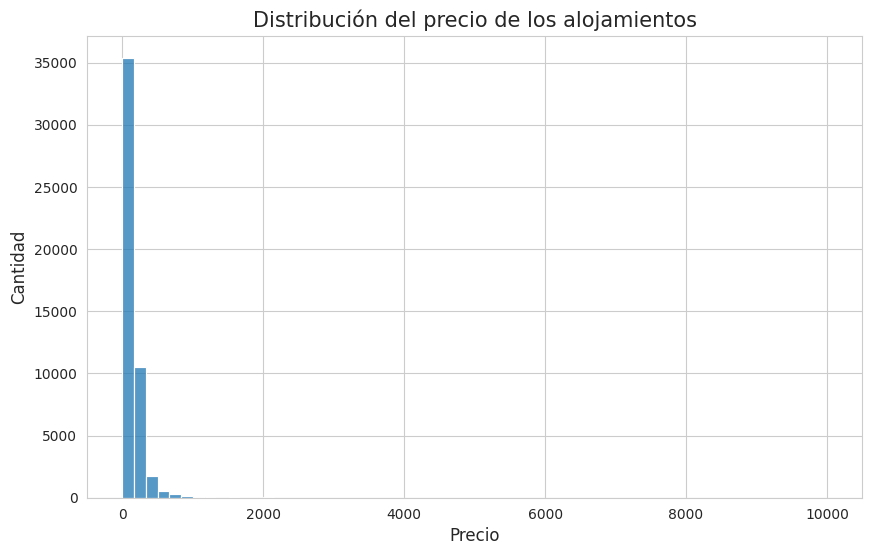

In [33]:
plt.figure(figsize=(10,6))

sns.histplot(df["price"], bins=60)

plt.title("Distribución del precio de los alojamientos")

plt.xlabel("Precio")

plt.ylabel("Cantidad")

plt.show()

### Interpretación

La distribución del precio presenta una fuerte asimetría positiva. La mayoría de los alojamientos posee precios relativamente bajos, mientras que una pequeña cantidad presenta valores extremadamente elevados. Esto sugiere la presencia de valores atípicos que serán considerados posteriormente durante la etapa de modelado.

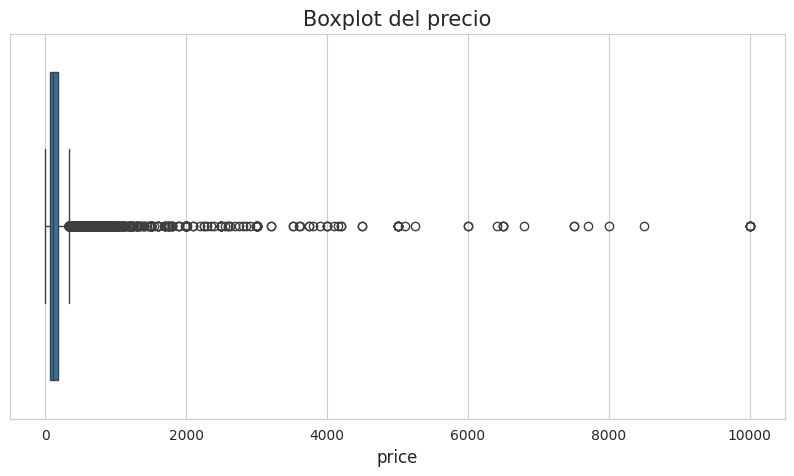

In [34]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["price"])

plt.title("Boxplot del precio")

plt.show()

### Interpretación

El boxplot confirma la existencia de numerosos valores extremos en la variable precio. Estos registros no serán eliminados en esta etapa, ya que primero se analizará su comportamiento dentro del conjunto de datos.

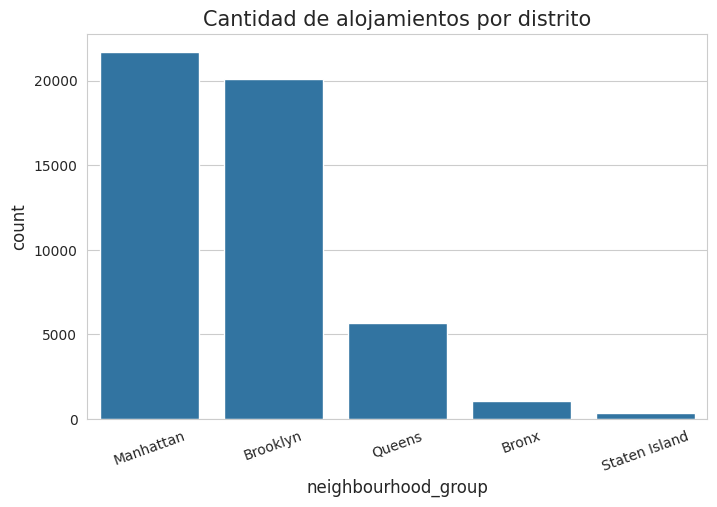

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="neighbourhood_group",
              order=df["neighbourhood_group"].value_counts().index)

plt.title("Cantidad de alojamientos por distrito")

plt.xticks(rotation=20)

plt.show()

### Interpretación

Manhattan y Brooklyn concentran la mayor cantidad de alojamientos publicados, mientras que los demás poseen una participación considerablemente menor dentro del mercado.

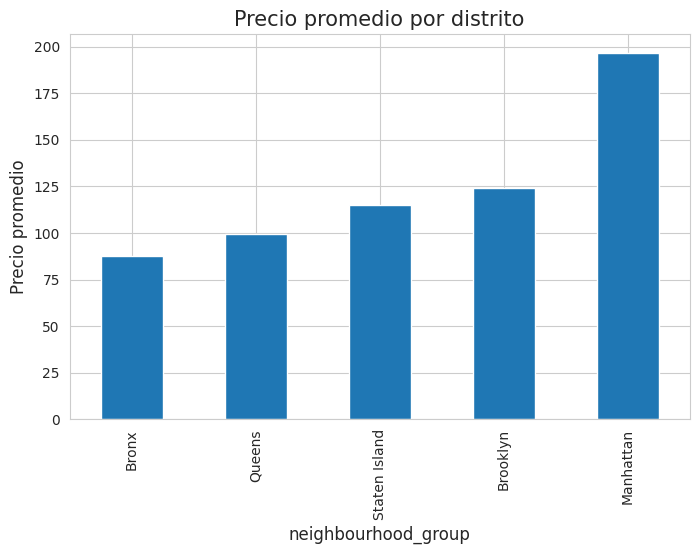

In [36]:
precio_barrio = df.groupby("neighbourhood_group")["price"].mean().sort_values()

plt.figure(figsize=(8,5))

precio_barrio.plot(kind="bar")

plt.title("Precio promedio por distrito")

plt.ylabel("Precio promedio")

plt.show()

### Interpretación

Se observan diferencias importantes entre los distintos distritos. Manhattan presenta el mayor precio promedio, mientras que los demás muestran valores considerablemente inferiores.

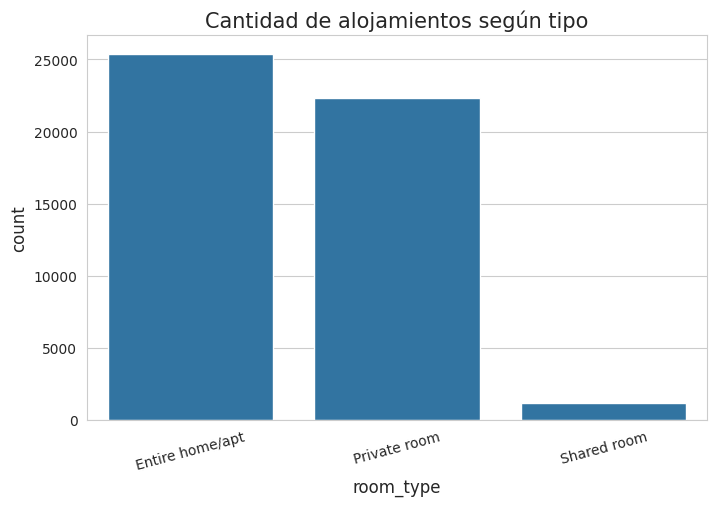

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="room_type",
              order=df["room_type"].value_counts().index)

plt.title("Cantidad de alojamientos según tipo")

plt.xticks(rotation=15)

plt.show()

### Interpretación

La mayor parte de las publicaciones corresponde a viviendas completas, seguidas por habitaciones privadas. Las habitaciones compartidas representan una proporción muy pequeña del total.

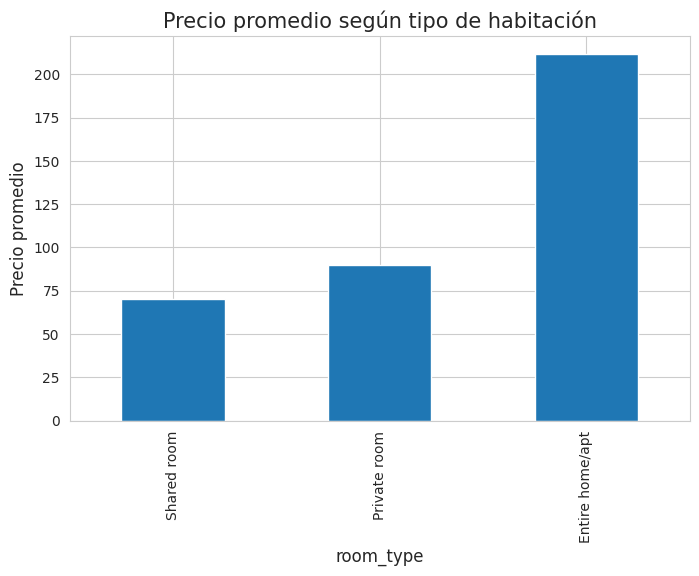

In [38]:
precio_room = df.groupby("room_type")["price"].mean().sort_values()

plt.figure(figsize=(8,5))

precio_room.plot(kind="bar")

plt.ylabel("Precio promedio")

plt.title("Precio promedio según tipo de habitación")

plt.show()

### Interpretación

Los alojamientos completos presentan el precio promedio más elevado, mientras que las habitaciones compartidas son la alternativa más económica.

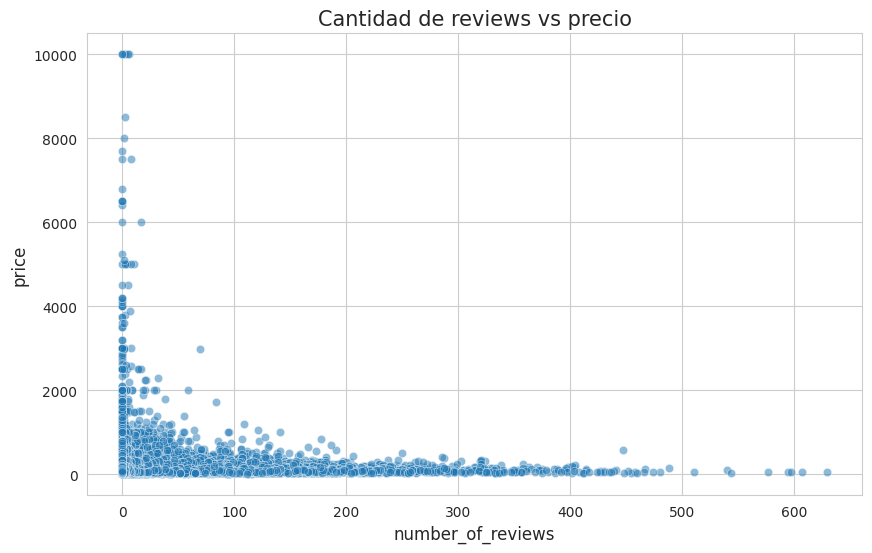

In [39]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x="number_of_reviews",
                y="price",
                alpha=0.5)

plt.title("Cantidad de reviews vs precio")

plt.show()

### Interpretación

No se observa una relación lineal evidente entre la cantidad de reseñas y el precio del alojamiento. Esto indica que otros factores podrían tener una mayor influencia sobre el valor publicado.

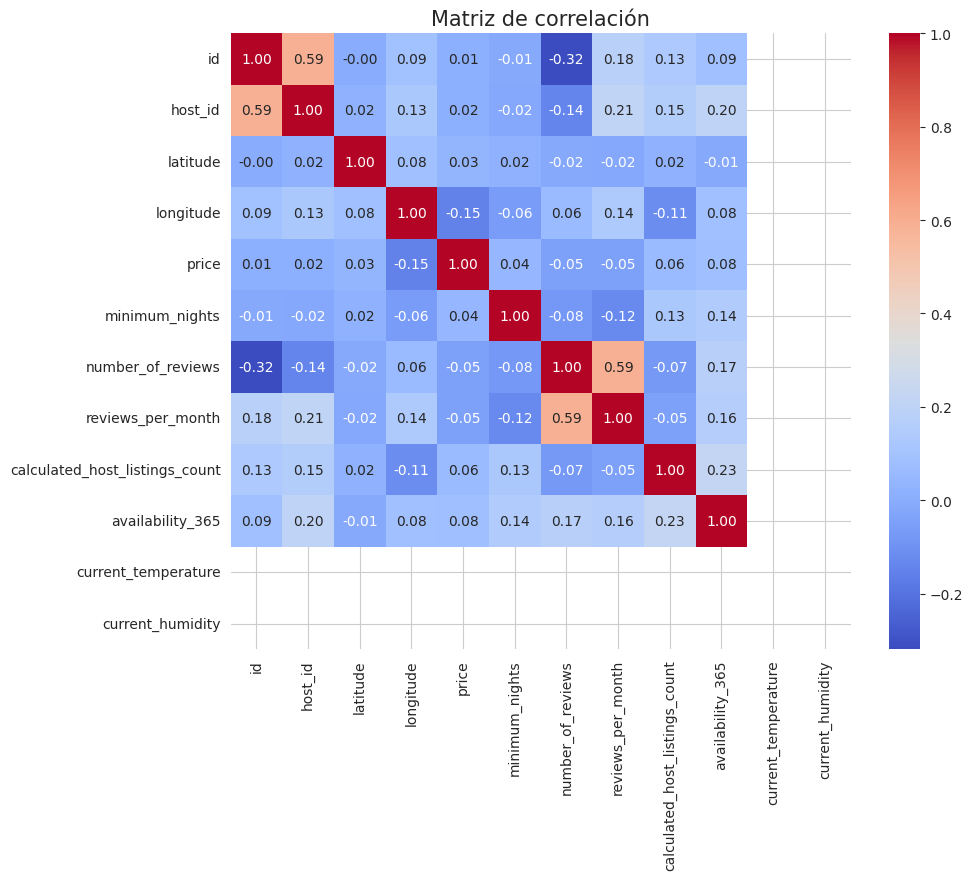

In [40]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=["number"]).corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Matriz de correlación")

plt.show()

### Interpretación

La matriz de correlación permite identificar la intensidad de las relaciones lineales entre las variables numéricas. En general se observan correlaciones bajas, lo que indica que el precio depende de múltiples factores y no de una única variable.

## Análisis específico de las variables

A continuación se profundiza el análisis exploratorio mediante visualizaciones orientadas a responder las preguntas de negocio planteadas al inicio del proyecto.

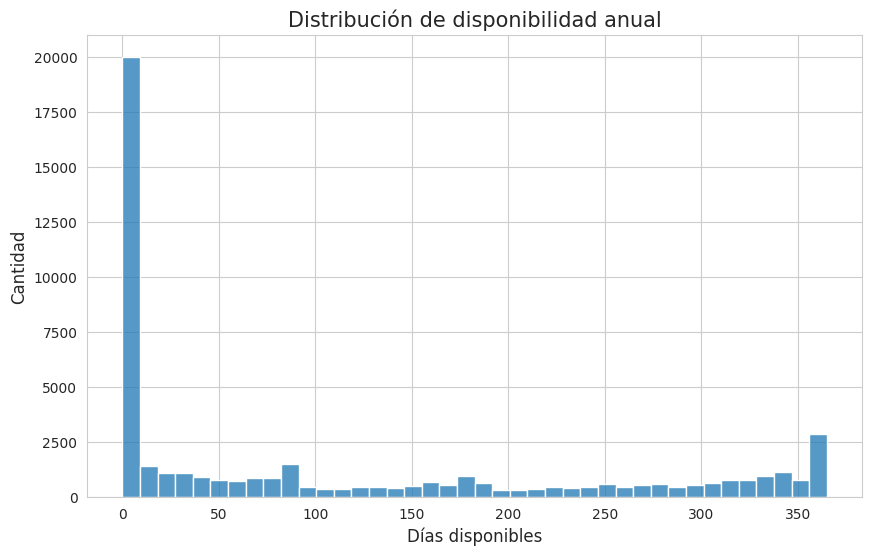

In [41]:
plt.figure(figsize=(10,6))

sns.histplot(df["availability_365"], bins=40)

plt.title("Distribución de disponibilidad anual")

plt.xlabel("Días disponibles")

plt.ylabel("Cantidad")

plt.show()

### Interpretación

La disponibilidad presenta una distribución heterogénea. Se observan numerosos alojamientos con disponibilidad muy baja y otros disponibles prácticamente durante todo el año.

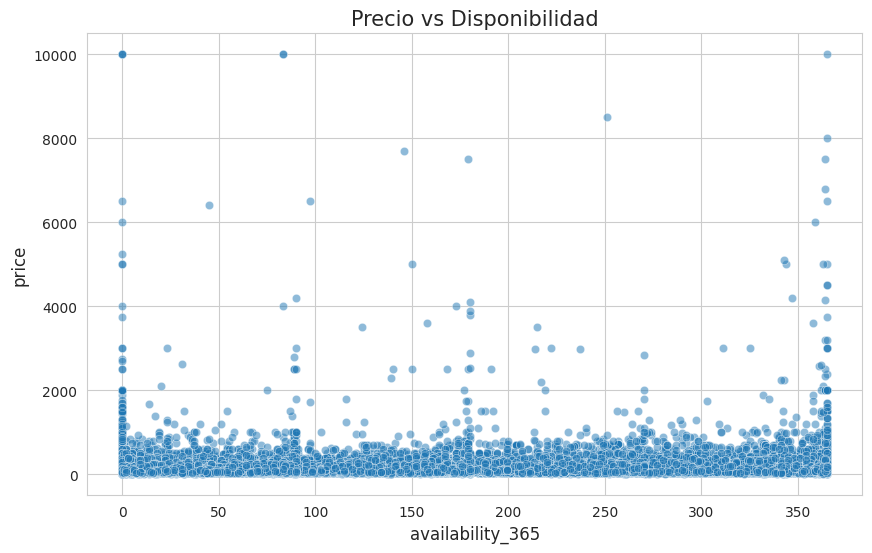

In [42]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="availability_365",
    y="price",
    alpha=0.5
)

plt.title("Precio vs Disponibilidad")

plt.show()

### Interpretación

No se observa una relación lineal clara entre la disponibilidad anual y el precio. Esto sugiere que la disponibilidad, por sí sola, no explica el valor del alojamiento.

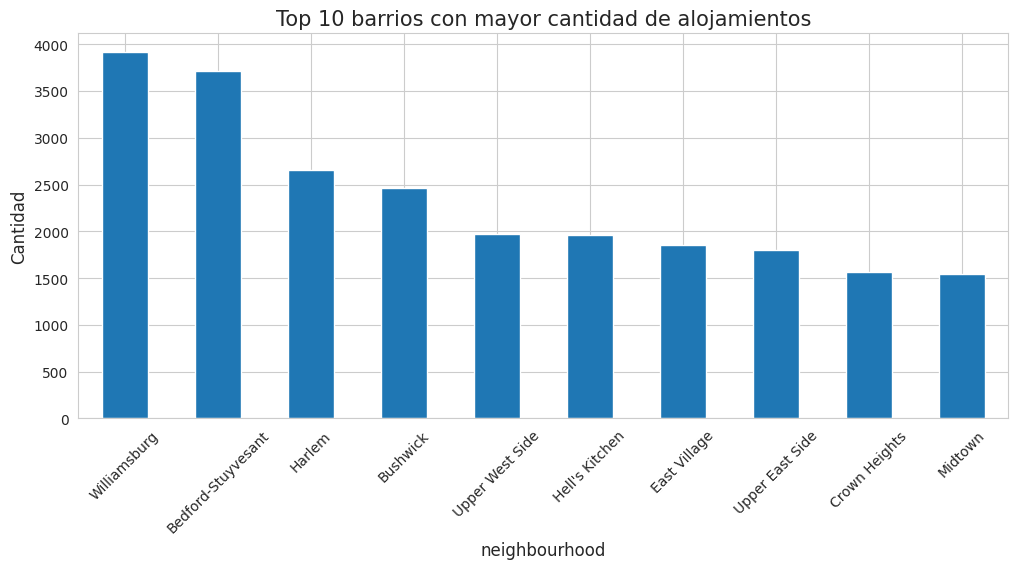

In [43]:
top_barrios = (
    df["neighbourhood"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

top_barrios.plot(kind="bar")

plt.title("Top 10 barrios con mayor cantidad de alojamientos")

plt.ylabel("Cantidad")

plt.xticks(rotation=45)

plt.show()

### Interpretación

La oferta de alojamientos se concentra en un conjunto reducido de barrios, evidenciando zonas con una fuerte presencia dentro de la plataforma Airbnb.

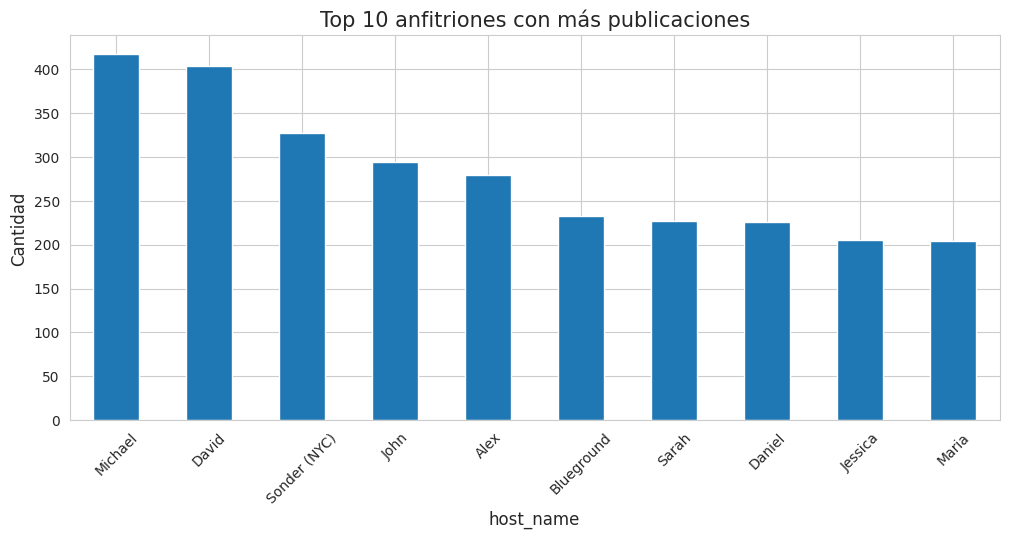

In [44]:
top_hosts = (
    df.groupby("host_name")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

top_hosts.plot(kind="bar")

plt.title("Top 10 anfitriones con más publicaciones")

plt.ylabel("Cantidad")

plt.xticks(rotation=45)

plt.show()

### Interpretación

Existen anfitriones con una gran cantidad de propiedades publicadas, lo que evidencia la presencia de operadores profesionales además de anfitriones particulares.

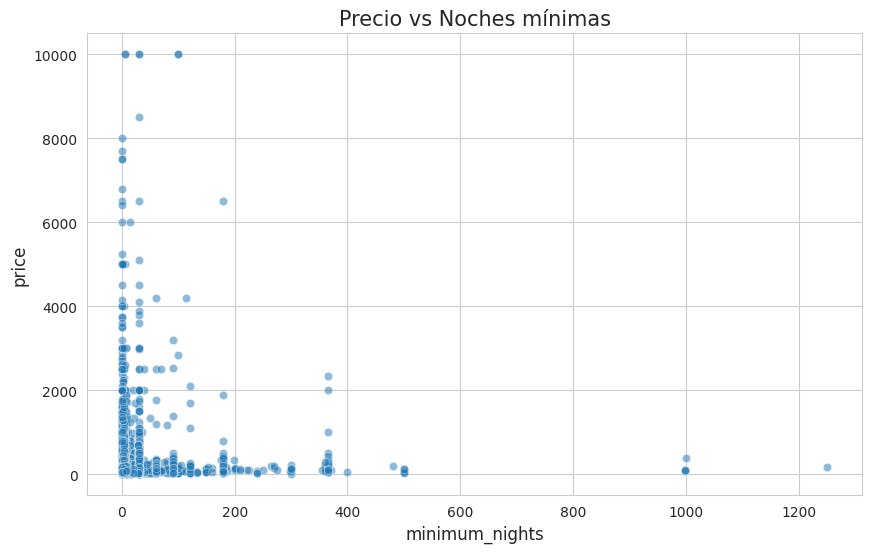

In [45]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="minimum_nights",
    y="price",
    alpha=0.5
)

plt.title("Precio vs Noches mínimas")

plt.show()

### Interpretación

No se observa una relación lineal evidente entre la cantidad mínima de noches y el precio. Sin embargo, aparecen algunos valores extremos que serán considerados durante el modelado.

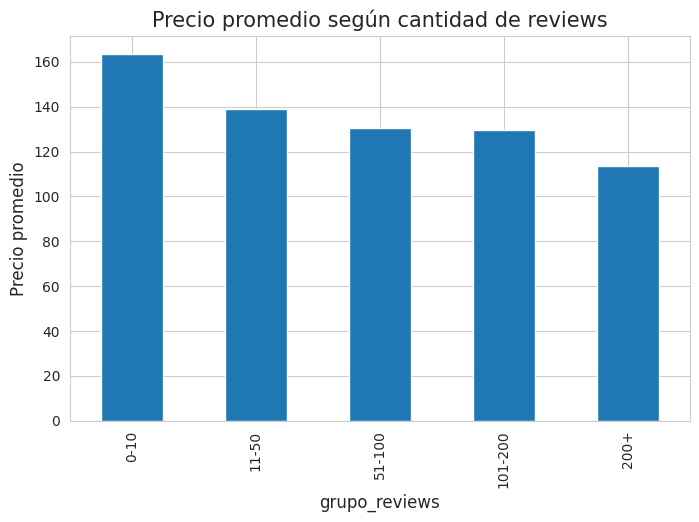

In [46]:
df["grupo_reviews"] = pd.cut(
    df["number_of_reviews"],
    bins=[-1,10,50,100,200,700],
    labels=["0-10","11-50","51-100","101-200","200+"]
)

precio_reviews = (
    df.groupby("grupo_reviews")["price"]
    .mean()
)

plt.figure(figsize=(8,5))

precio_reviews.plot(kind="bar")

plt.title("Precio promedio según cantidad de reviews")

plt.ylabel("Precio promedio")

plt.show()

### Interpretación

Los grupos de reseñas presentan diferencias moderadas en el precio promedio, aunque no se observa un patrón suficientemente fuerte como para afirmar una relación directa.

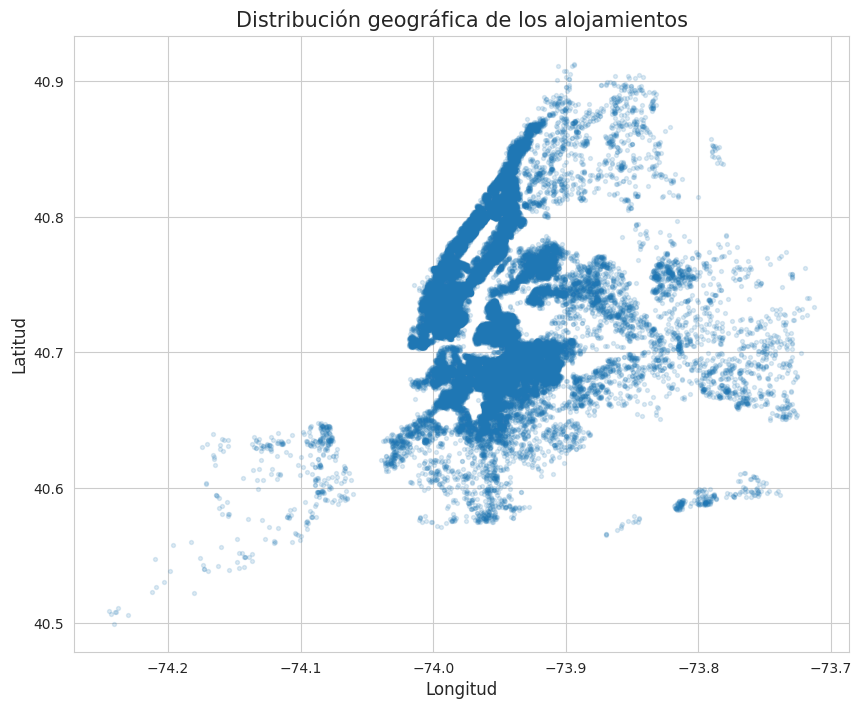

In [47]:
plt.figure(figsize=(10,8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.15,
    s=8
)

plt.title("Distribución geográfica de los alojamientos")

plt.xlabel("Longitud")

plt.ylabel("Latitud")

plt.show()

### Interpretación

La distribución espacial muestra una fuerte concentración de alojamientos en Manhattan y Brooklyn, coincidiendo con los principales centros turísticos y urbanos de la ciudad.

# Insights obtenidos

## Principales hallazgos

- Manhattan presenta los precios promedio más elevados de toda la ciudad.

- Brooklyn concentra una gran cantidad de publicaciones con precios intermedios.

- Los alojamientos completos poseen valores significativamente superiores a las habitaciones privadas o compartidas.

- El precio presenta una distribución altamente asimétrica debido a la existencia de valores extremos.

- Variables como la cantidad de reviews o la disponibilidad anual muestran una influencia limitada sobre el precio cuando se analizan individualmente.

- Existen anfitriones con cientos de propiedades publicadas, indicando la presencia de operadores profesionales dentro de la plataforma.

- La mayor parte de la oferta se concentra en pocos barrios específicos de Nueva York.

- El conjunto de datos contiene suficientes variables como para entrenar modelos predictivos capaces de estimar el precio de un alojamiento.

# Preparación para Machine Learning

Con el objetivo de entrenar modelos predictivos, se preparó un nuevo conjunto de datos eliminando variables identificadoras, tratando valores atípicos y dejando el dataset listo para el proceso de modelado.

In [48]:
df_ml = df.copy()

In [49]:
df_ml = df_ml.drop(columns=[
    "id",
    "host_id",
    "name",
    "host_name",
    "last_review"
])

In [50]:
df_ml = df_ml[df_ml["price"] > 0]

In [51]:
df_ml = df_ml[df_ml["price"] <= 3000]

In [52]:
df_ml = df_ml[df_ml["minimum_nights"] <= 365]

In [53]:
print(df_ml.shape)

(48825, 14)


In [54]:
df_ml.isnull().sum()

,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,0
calculated_host_listings_count,0


In [55]:
df_ml.to_csv(
    "airbnb_limpio_ml.csv",
    index=False
)

# Machine Learning

## Definición del problema

El objetivo consiste en desarrollar un modelo de regresión capaz de predecir el precio de un alojamiento a partir de sus características.

In [56]:
# VARIABLE OBJETIVO

X = df_ml.drop("price", axis=1)

y = df_ml["price"]

In [57]:
print(X.shape)

print(y.shape)

(48825, 13)
(48825,)


In [58]:
print("Variables numéricas")

display(X.select_dtypes(include=["int64","float64"]).columns)

print()

print("Variables categóricas")

display(X.select_dtypes(include=["object","category"]).columns)

Variables numéricas


Index(['latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'current_temperature', 'current_humidity'],
      dtype='object')


Variables categóricas


Index(['neighbourhood_group', 'neighbourhood', 'room_type', 'grupo_reviews'], dtype='object')

# Ingeniería de atributos

In [59]:
df_ml["professional_host"] = (
    df_ml["calculated_host_listings_count"] > 1
).astype(int)

In [60]:
df_ml["high_availability"] = (
    df_ml["availability_365"] > 180
).astype(int)

In [61]:
df_ml["popular_listing"] = (
    df_ml["number_of_reviews"] > 50
).astype(int)

In [62]:
X = df_ml.drop("price", axis=1)

y = df_ml["price"]

In [63]:
categorical_features = X.select_dtypes(
    include=["object","category"]
).columns

numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns

# Preprocesamiento de datos

En esta etapa se aplican técnicas de normalización para las variables numéricas y codificación One-Hot para las variables categóricas mediante ColumnTransformer.

In [64]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [66]:
print(X_train.shape)

print(X_test.shape)

(39060, 16)
(9765, 16)


# Entrenamiento de modelos

In [67]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [68]:
linear_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'current_temperature', 'current_humidity',
       'professional_host', 'high_availability', 'popular_listing'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['neighbourhood_group', 'neighbourhood', 'room_type', 'grupo_reviews'], dtype='object'))])),
                ('model', LinearRegression())])

In [69]:
pred_lr = linear_pipeline.predict(
    X_test
)

In [70]:
print("R2:",
      r2_score(y_test, pred_lr))

print("MAE:",
      mean_absolute_error(y_test, pred_lr))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, pred_lr))
)

R2: 0.22891954179954566
MAE: 63.350970733372485
RMSE: 135.95937648148393


In [71]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            random_state=42
        )
    )
])

In [72]:
rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'current_temperature', 'current_humidity',
       'professional_host', 'high_availability', 'popular_listing'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['neighbourhood_group', 'neighbourhood', 'room_type', 'grupo_reviews'], dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [73]:
pred_rf = rf_pipeline.predict(
    X_test
)

In [74]:
print("R2:",
      r2_score(y_test, pred_rf))

print("MAE:",
      mean_absolute_error(y_test, pred_rf))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, pred_rf))
)

R2: 0.2790018875719633
MAE: 58.468081583888036
RMSE: 131.46991425915797


In [75]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBRegressor(
            random_state=42,
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6
        )
    )
])

In [76]:
xgb_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'current_temperature', 'current_humidity',
       'professional_host', 'high_availability', 'popular_listing'],
      dtype='object')),
                                                 ('cat'...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [77]:
pred_xgb = xgb_pipeline.predict(
    X_test
)

In [78]:
print("R2:",
      r2_score(y_test, pred_xgb))

print("MAE:",
      mean_absolute_error(y_test, pred_xgb))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, pred_xgb))
)

R2: 0.3207511901855469
MAE: 56.674678802490234
RMSE: 127.60678738805393


# Validación cruzada

Para obtener una estimación más robusta del desempeño del modelo se aplicó validación cruzada utilizando cinco particiones (5-Fold Cross Validation).

In [79]:
scores = cross_val_score(
    xgb_pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)

print()

print("R2 Promedio:", scores.mean())

[0.1826188  0.25308579 0.2919662  0.29109347 0.171911  ]

R2 Promedio: 0.23813505172729493


# Optimización de hiperparámetros

Se utilizó RandomizedSearchCV para encontrar automáticamente la combinación de hiperparámetros que produce el mejor desempeño del modelo XGBoost.

In [80]:
parametros = {

    "model__n_estimators":[100,200,300],

    "model__max_depth":[3,5,7],

    "model__learning_rate":[0.05,0.1,0.2],

    "model__subsample":[0.8,1.0]
}

In [81]:
random_search = RandomizedSearchCV(

    estimator=xgb_pipeline,

    param_distributions=parametros,

    n_iter=10,

    cv=3,

    scoring="r2",

    random_state=42,

    n_jobs=-1
)

In [82]:
random_search.fit(
    X_train,
    y_train
)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               Index(['latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'current_temperature', 'current_humidity',
       'professional_host', 'high_availability', 'popular...
                                                           max_depth=6,
                                                           max_leaves=None,
                                                           min_child_weight=None,
                                                           missing=nan,
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=100,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.05, 0.1,
                                                                 0.2],
                                        'model__max_depth': [3, 5, 7],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__subsample': [0.8, 1.0]},
                   random_state=42, scoring='r2')

In [83]:
print(random_search.best_params_)

print()

print(random_search.best_score_)

{'model__subsample': 0.8, 'model__n_estimators': 100, 'model__max_depth': 7, 'model__learning_rate': 0.05}

0.2943517565727234


In [84]:
best_model = random_search.best_estimator_

pred_best = best_model.predict(X_test)

In [85]:
print("R2:",r2_score(y_test,pred_best))

print("MAE",mean_absolute_error(y_test,pred_best))

print("RMSE",
      np.sqrt(mean_squared_error(y_test,pred_best)))

R2: 0.32641690969467163
MAE 56.43622589111328
RMSE 127.07347852841875


#Comparación de modelos

In [86]:
resultados = pd.DataFrame({

"Modelo":[
"Linear Regression",
"Random Forest",
"XGBoost"
],

"R2":[

r2_score(y_test,pred_lr),

r2_score(y_test,pred_rf),

r2_score(y_test,pred_xgb)

],

"MAE":[

mean_absolute_error(y_test,pred_lr),

mean_absolute_error(y_test,pred_rf),

mean_absolute_error(y_test,pred_xgb)

],

"RMSE":[

np.sqrt(mean_squared_error(y_test,pred_lr)),

np.sqrt(mean_squared_error(y_test,pred_rf)),

np.sqrt(mean_squared_error(y_test,pred_xgb))

]

})

resultados

,Modelo,R2,MAE,RMSE
0,Linear Regression,0.228920,63.350971,135.959376
1,Random Forest,0.279002,58.468082,131.469914
2,XGBoost,0.320751,56.674679,127.606787


In [87]:
resultados.sort_values(
    by="R2",
    ascending=False
)

,Modelo,R2,MAE,RMSE
2,XGBoost,0.320751,56.674679,127.606787
1,Random Forest,0.279002,58.468082,131.469914
0,Linear Regression,0.228920,63.350971,135.959376


#Interpretabilidad del modelo

In [88]:
modelo = best_model.named_steps["model"]

In [89]:
variables = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

In [90]:
importancias = pd.DataFrame({

"Variable":variables,

"Importancia":modelo.feature_importances_

})

In [91]:
importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

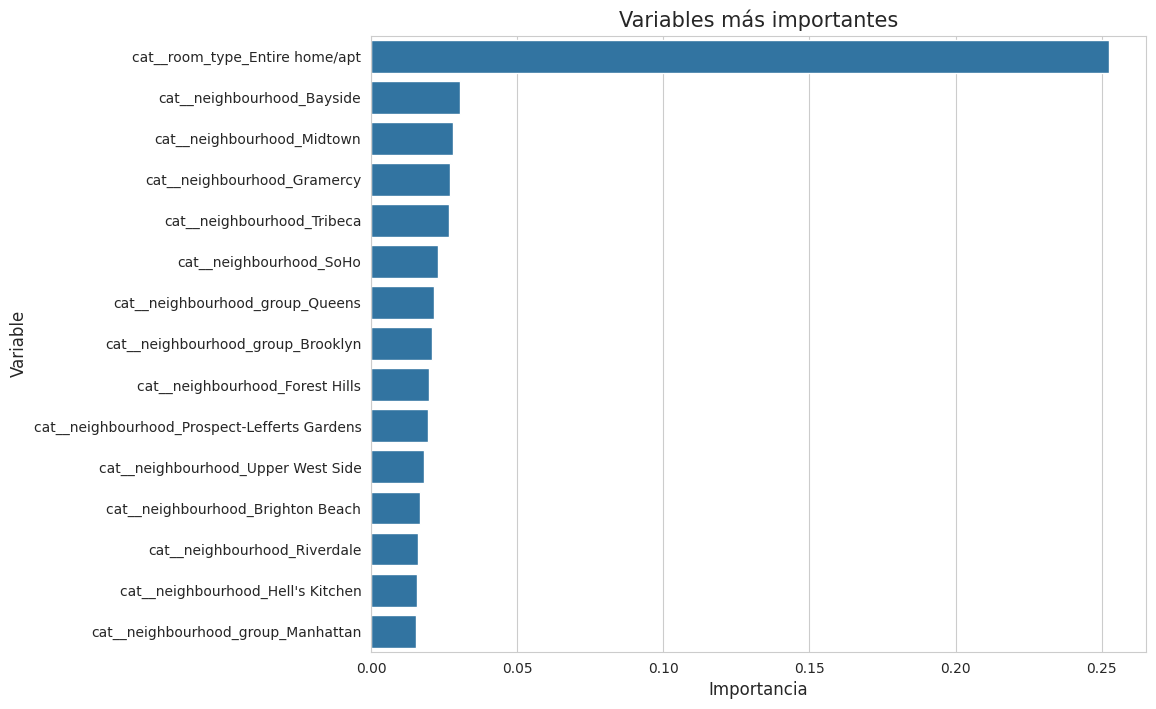

In [92]:
plt.figure(figsize=(10,8))

sns.barplot(

data=importancias.head(15),

x="Importancia",

y="Variable"

)

plt.title("Variables más importantes")

plt.show()

In [93]:
X_train_transformado = best_model.named_steps[
    "preprocessor"
].transform(X_train)

In [94]:
explainer = shap.TreeExplainer(modelo)

In [95]:
shap_values = explainer.shap_values(
    X_train_transformado
)

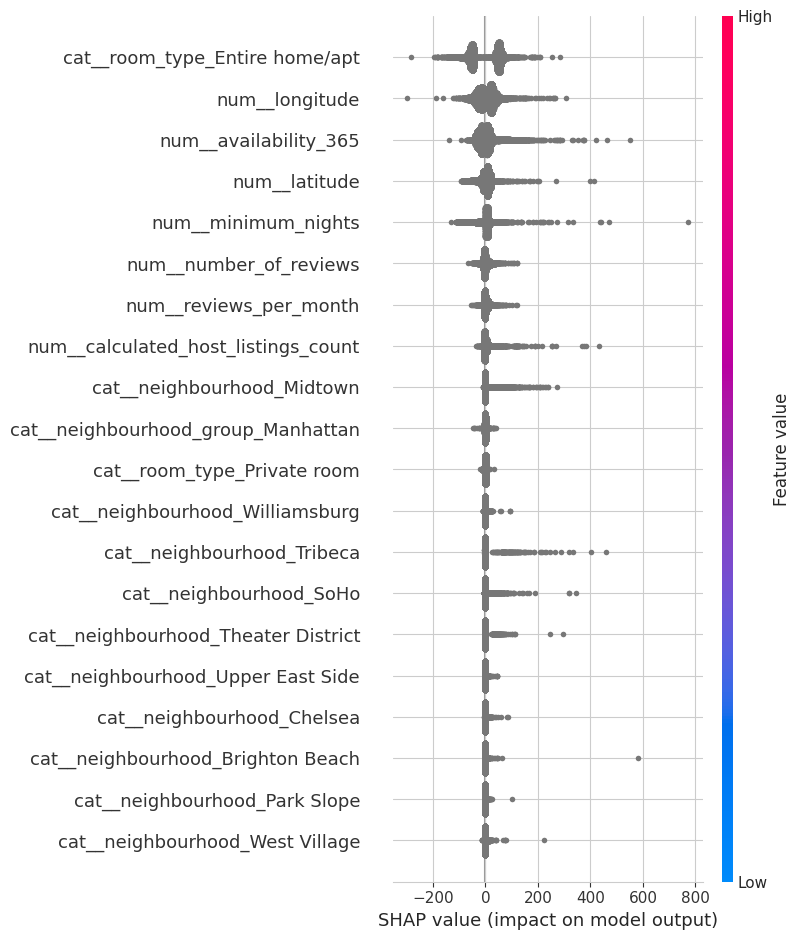

In [96]:
shap.summary_plot(
    shap_values,
    X_train_transformado,
    feature_names=variables
)

# Conclusiones

El análisis permitió identificar diferencias significativas en los precios según la ubicación y el tipo de alojamiento.

Manhattan presentó los precios promedio más elevados, mientras que Brooklyn concentró una gran cantidad de publicaciones.

Posteriormente se entrenaron tres modelos de Machine Learning para resolver un problema de regresión orientado a estimar el precio de los alojamientos.

Tras comparar los resultados obtenidos mediante las métricas R², MAE y RMSE, XGBoost fue seleccionado como el modelo con mejor desempeño.

En conclusión, la combinación de análisis exploratorio y Machine Learning permitió comprender el comportamiento del mercado y construir un modelo predictivo útil para estimar el precio de un alojamiento.